<a href="https://colab.research.google.com/github/safaaelbanaoui/heart-disease-data-mining/blob/main/heart_disease_data_mining_ELBANAOUI_safaa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Dataset – Data Mining Pipeline

Dans ce notebook, j’analyse la base de données Heart Disease du repository UCI, qui contient plusieurs variables cliniques liées à la santé cardiovasculaire des patients (âge, pression artérielle, cholestérol, fréquence cardiaque, etc.).

L’objectif est d’explorer ces données et de construire un modèle capable de prédire la présence d’une maladie cardiaque.

Pour cela, je vais suivre un pipeline classique de data mining comprenant :
- l’analyse exploratoire des données (EDA)
- le prétraitement des données
- la modélisation avec des méthodes de machine learning
- l’évaluation et l’interprétation des résultats.

Dans cette section, je charge les bibliothèques nécessaires à l'analyse ainsi que le dataset directement depuis le repository UCI et j'affiche les premières lignes afin de vérifier que les données ont bien été importées.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = [
"age","sex","cp","trestbps","chol","fbs","restecg",
"thalach","exang","oldpeak","slope","ca","thal","target"
]

df = pd.read_csv(url, names=columns)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


#Observation:

J'ai exécuté `df.info()` afin de vérifier la structure du dataset et les types de variables.  
On remarque que (ca) et ( thal) sont de type object probablement à cause de valeurs manquantes encodées (?), donc elle seront nettoyées.

J'ai ensuite utilisé `df.describe()` pour obtenir des statistiques descriptives des variables numériques. On observe notamment que l'âge moyen est d'environ 54 ans et que la variable (target) varie de 0 à 4. Elle sera convertie en variable binaire (0 1) afin de traiter le problème comme une classification.

## Nettoyage de données


In [ ]:
(df == "?").sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
import numpy as np

df = df.replace("?", np.nan)

In [ ]:
df["ca"] = pd.to_numeric(df["ca"])
df["thal"] = pd.to_numeric(df["thal"])

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df = df.dropna()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 34.8 KB


In [ ]:
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

#Observation( Nettoyage des données):
J'ai remplacé les valeurs (?)  par NaN et converti les colonnes (ca) et (thal) en variables numériques.  
Puis j'ai supprimé les lignes contenant des valeurs manquantes avec `dropna()` , 6 lignes supprimées (de 303 à 297), ce qui reste négligeable.

Toutes les variables sont désormais de type numérique et aucune valeur manquante ne subsiste.  
Enfin, j'ai binarisé la variable (target) (0 = absence de maladie, 1 = présence de maladie).
  

##EDA


**1.Distribution de la variable cible**

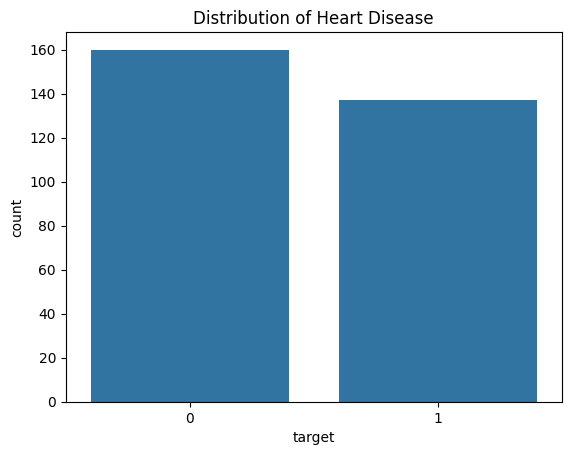

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="target", data=df)
plt.title("Distribution of Heart Disease")
plt.show()

On observe que les deux classes (absence (160) et présence (137)de maladie cardiaque) sont relativement équilibrées, ce qui est favorable pour l'entraînement d'un modèle de classification.

**2. Distribution des variables**


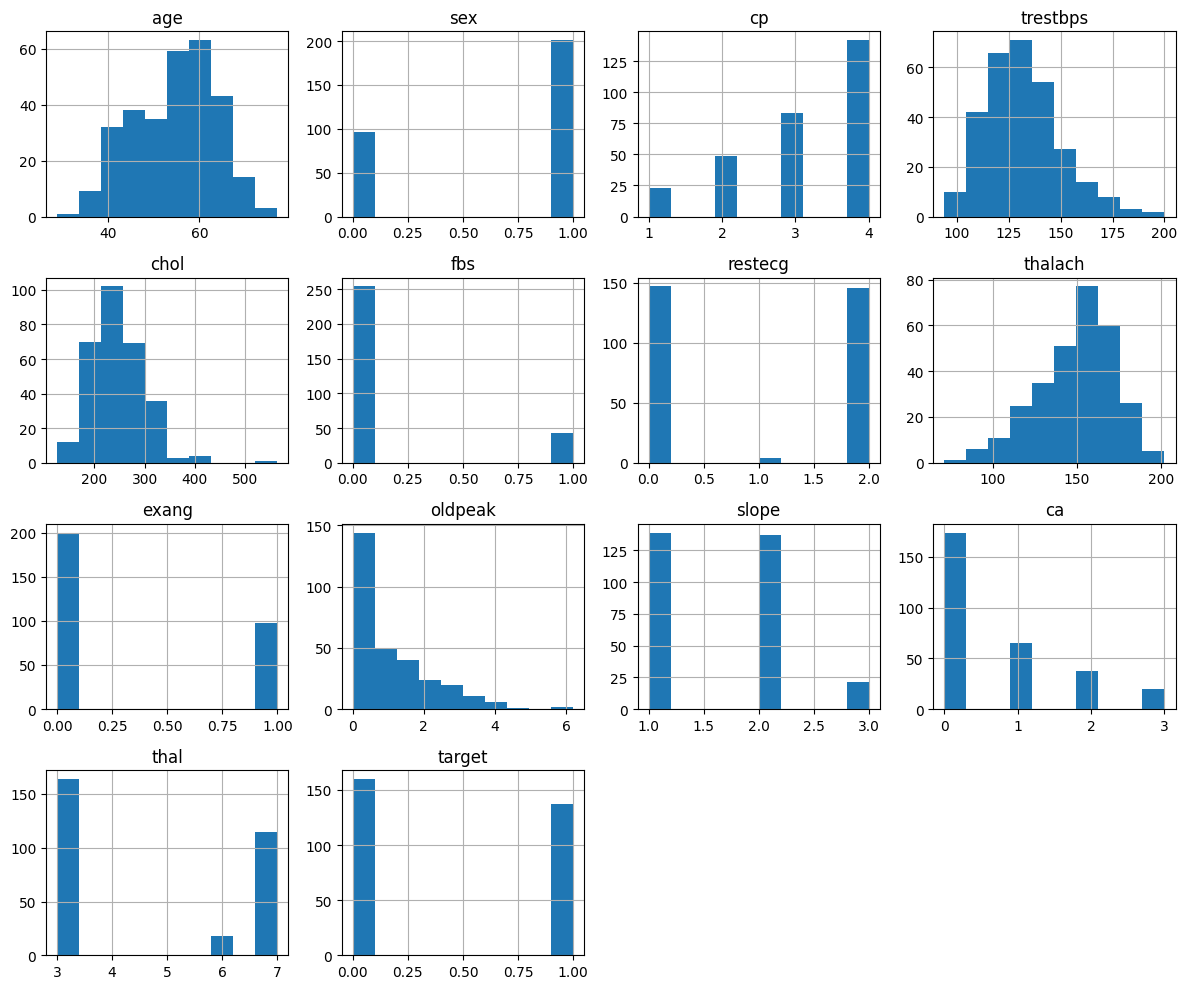

In [ ]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

Les histogrammes montrent que la majorité des patients ont entre 40 et 65 ans, que la variable (chol) présente une distribution asymétrique avec quelques valeurs extrêmes au-delà de 400, et que certaines variables comme (sex), (fbs) et (exang) sont fortement déséquilibrées.

**3. Matrice de corrélation**

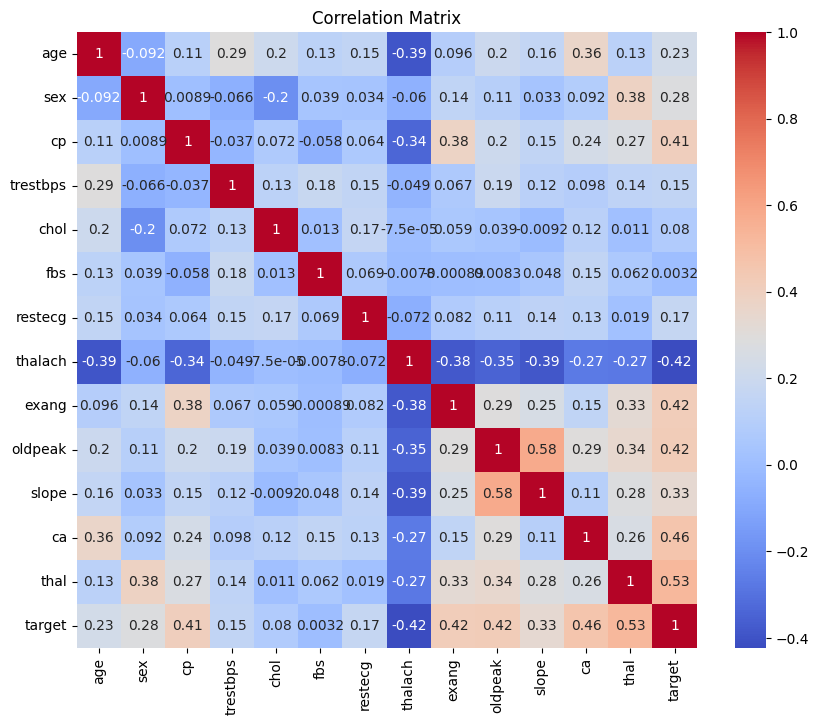

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Cela montre que les variables les plus corrélées avec **target** sont **thal** (0.53), **ca** (0.46), **exang** (0.42) et **oldpeak** (0.42), tandis que **thalach** présente une corrélation négative (-0.42), suggérant qu’une fréquence cardiaque maximale élevée est associée à une probabilité plus faible de maladie cardiaque.

**4. Âge vs Maladie cardiaque**

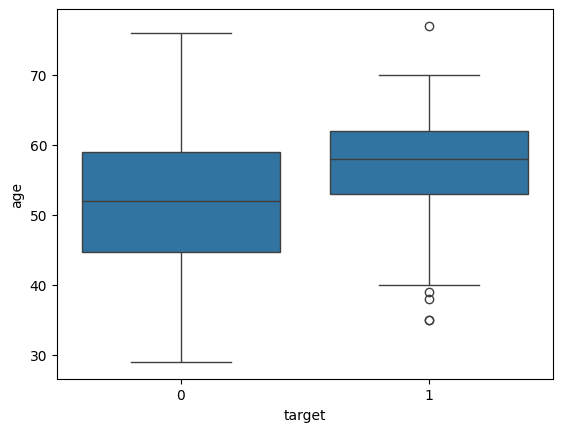

In [ ]:
sns.boxplot(x="target", y="age", data=df)
plt.show()

Les patients atteints d'une maladie cardiaque (1) tendent à être légèrement plus âgés, avec une médiane autour de 58 ans contre environ 52 ans pour les patients sans maladie, bien que les distributions se chevauchent significativement.

**5. Cholestérol vs Maladie cardiaque**

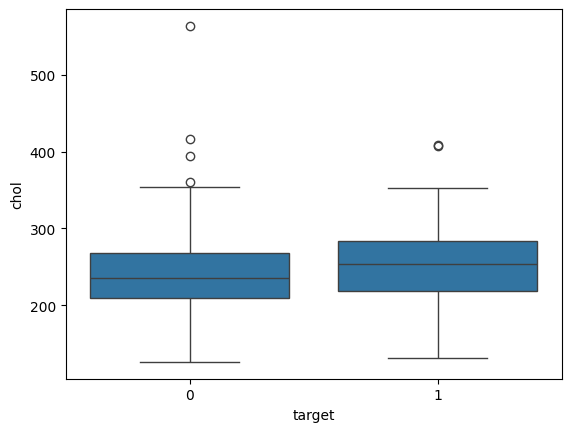

In [ ]:
sns.boxplot(x="target", y="chol", data=df)
plt.show()

Le cholestérol ne semble pas être un facteur fortement discriminant entre les deux groupes, les distributions étant très similaires. On observe toutefois la présence d'outliers importants dans les deux cas, notamment une valeur dépassant 560.

**6. cp vs target**

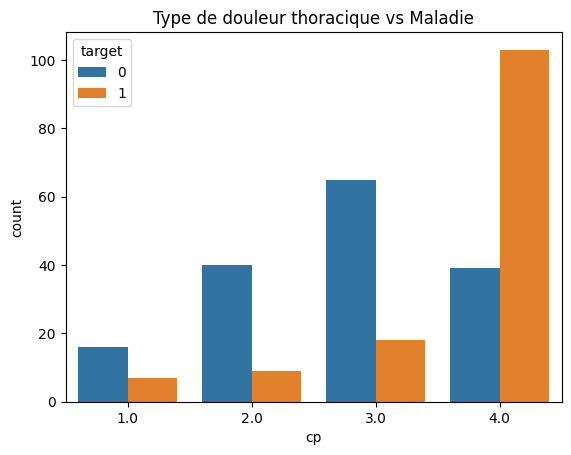

In [ ]:
sns.countplot(x="cp", hue="target", data=df)
plt.title("Type de douleur thoracique vs Maladie")
plt.show()

Les patients asymptomatiques (**cp = 4**) présentent paradoxalement le plus grand nombre de cas de maladie cardiaque, ce qui confirme la forte relation entre (cp) et (target) et souligne l'importance clinique de cette variable.

**7. thalach vs target**

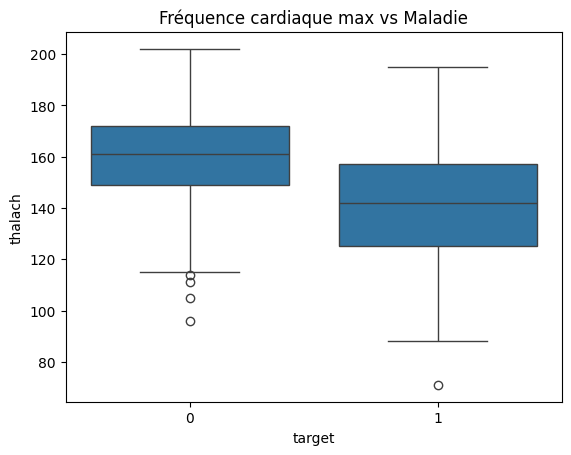

In [ ]:
sns.boxplot(x="target", y="thalach", data=df)
plt.title("Fréquence cardiaque max vs Maladie")
plt.show()

Les patients atteints d'une maladie cardiaque (1) présentent une fréquence cardiaque maximale plus faible (médiane ≈ 142) que les patients sans maladie (médiane ≈ 160), ce qui confirme la corrélation négative observée dans la matrice de corrélation.

**8. oldpeak vs target**

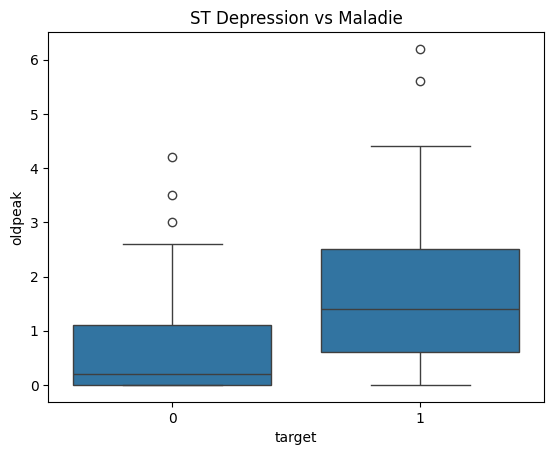

In [ ]:
sns.boxplot(x="target", y="oldpeak", data=df)
plt.title("ST Depression vs Maladie")
plt.show()

Les patients atteints d'une maladie cardiaque présentent des valeurs d’**oldpeak** nettement plus élevées (médiane ≈ 1.5) que les patients sans maladie (médiane ≈ 0.2, proche de 0 ), suggérant qu'une dépression plus importante du segment ST est associée à la présence d'une maladie cardiaque.

**9. exang vs target**

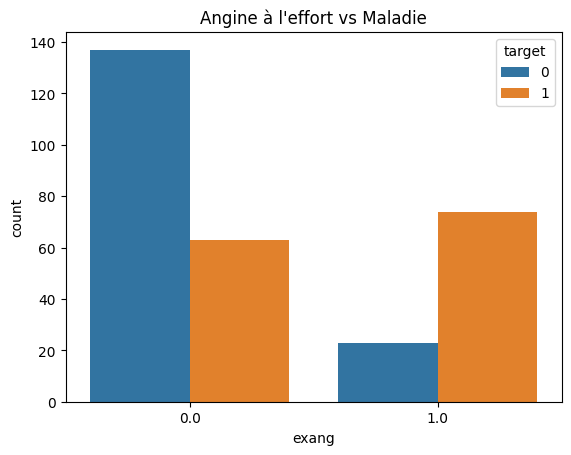

In [ ]:
sns.countplot(x="exang", hue="target", data=df)
plt.title("Angine à l'effort vs Maladie")
plt.show()

Les patients présentant une angine induite par l'effort (exang = 1) sont majoritairement atteints d'une maladie cardiaque, tandis que ceux sans angine (exang = 0) sont plus souvent sans maladie, ce qui suggère que cette variable constitue un indicateur clinique important.

**10. sex vs target**

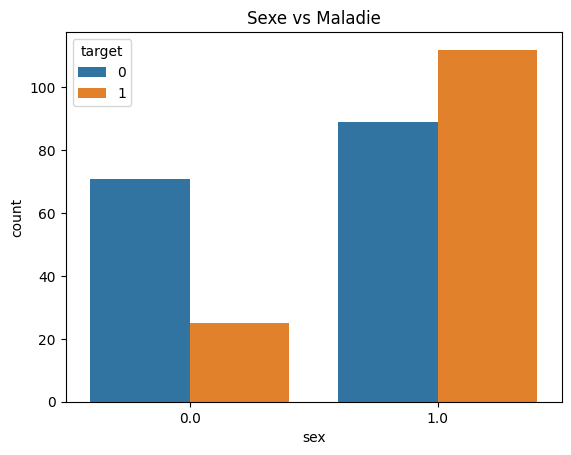

In [ ]:
sns.countplot(x="sex", hue="target", data=df)
plt.title("Sexe vs Maladie")
plt.show()

Les hommes (**sex = 1**) sont proportionnellement plus touchés par la maladie cardiaque que les femmes (**sex = 0**) dans ce dataset, suggérant que le sexe pourrait être un facteur associé au risque de maladie cardiaque.

### Conclusion de l’EDA

En résumé, les variables les plus discriminantes pour prédire la maladie cardiaque semblent être **thal**, **ca**, **cp**, **exang**, **oldpeak** et **thalach**.  
Ces variables devraient jouer un rôle important lors de la phase de modélisation et dans l’interprétation des résultats.

##Prétraitement des données

**Préparation des données**

Dans cette étape, je sépare les variables explicatives (**X**) de la variable cible (**target**) afin de préparer les données pour l'entraînement des modèles de ML.

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

##Train / Test Split

**Séparation des données(train/test)**

Je divise ensuite les données en un ensemble d'entraînement (80 %) et un ensemble de test (20 %) pr évaluer la capacité du modèle à généraliser sur des données non vues.

J'ai choisi un ratio 80/20 plutôt qu'une division 60/20/20 car le dataset est de taille limitée (297 observs). La validation des hyperparamètres sera réalisée à l'aide d'une validation croisée (cross-validation).

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##Standardisation

**Standardisation des variables**

Les variables sont standardisées afin de mettre toutes les features sur une échelle comparable, ce qui est particulièrement important pour certains modèles comme la régression logistique.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

J'applique la standardisation après le split afin d'éviter tout data leakage — le scaler est entraîné uniquement sur les données d'entraînement et appliqué ensuite au test set.

In [ ]:
X_train.shape, X_test.shape

((237, 13), (60, 13))

Je vérifie les dimensions des ensembles d'entraînement et de test.

## Modélisation

Dans cette section, j'entraîne deux modèles de classification : une Régression Logistique comme modèle de référence (baseline), et un Random Forest comme modèle plus complexe ( pr non linéaires ).

**1. Régression Logistique**

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [ ]:
## Évaluation - Régression Logistique
print("=== Régression Logistique ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.2f}")
print(classification_report(y_test, y_pred_lr))

=== Régression Logistique ===
Accuracy : 0.87
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        36
           1       0.83      0.83      0.83        24

    accuracy                           0.87        60
   macro avg       0.86      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60



La régression logistique obtient une accuracy de 87%, avec une précision et un recall équilibrés pour les deux classes (0.89 pour les sains et 0.83 pour les malades), ce qui indique que le modèle généralise bien sur les données de test.

**2. Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
## Évaluation - Random Forest
print("=== Random Forest ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.2f}")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy : 0.88
              precision    recall  f1-score   support

           0       0.91      0.89      0.90        36
           1       0.84      0.88      0.86        24

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60



Le Random Forest obtient une accuracy de 88%, légèrement supérieure à la régression logistique. Il performe mieux sur la classe 1 (recall de 0.88 vs 0.83), ce qui est important dans un contexte médical où il vaut mieux minimiser les faux négatifs (ne pas manquer un patient malade)

**Matrices de confusion**

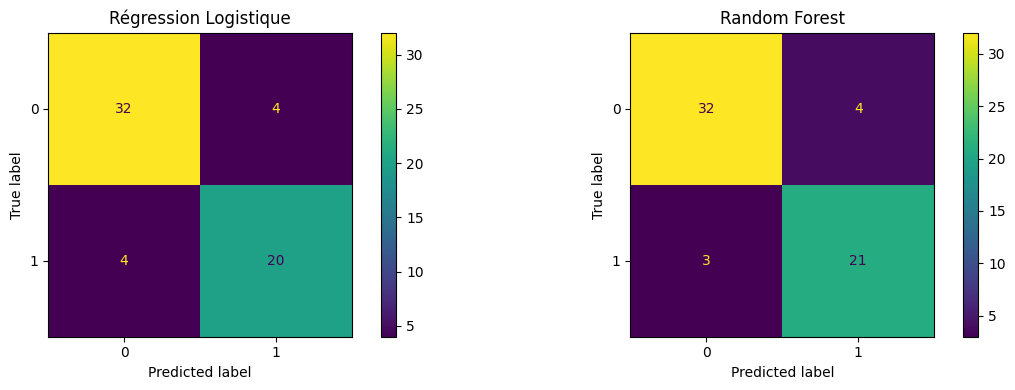

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0])
axes[0].set_title("Régression Logistique")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1])
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

Les deux modèles obtiennent des résultats similaires. Le Random Forest produit 3 faux négatifs (patients malades non détectés) contre 4 pour la régression logistique, ce qui le rend légèrement meilleur dans ce contexte médical où manquer un patient malade est plus critique qu'une fausse alarme.

### Optimisation des hyperparamètres (Random Forest)

J'utilise GridSearchCV avec une validation croisée à 5 folds pour identifier les meilleurs hyperparamètres du Random Forest.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                           param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur score CV :", grid_search.best_score_.round(2))

Meilleurs paramètres : {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
Meilleur score CV : 0.81


### Réentraînement avec les meilleurs paramètres

In [ ]:
rf_optimized = RandomForestClassifier(
    max_depth=3,
    min_samples_split=2,
    n_estimators=100,
    random_state=42
)
rf_optimized.fit(X_train, y_train)
y_pred_rf_opt = rf_optimized.predict(X_test)

print("=== Random Forest Optimisé ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf_opt):.2f}")
print(classification_report(y_test, y_pred_rf_opt))

=== Random Forest Optimisé ===
Accuracy : 0.87
              precision    recall  f1-score   support

           0       0.87      0.92      0.89        36
           1       0.86      0.79      0.83        24

    accuracy                           0.87        60
   macro avg       0.87      0.85      0.86        60
weighted avg       0.87      0.87      0.87        60



Le Random Forest optimisé obtient une accuracy de 87%, légèrement inférieure au modèle de base (88%). Cependant, il améliore le recall de la classe 0 (0.92 vs 0.89), ce qui signifie qu'il détecte mieux les patients sains. Ce résultat suggère que les paramètres par défaut étaient déjà bien adaptés à ce dataset de taille limitée.

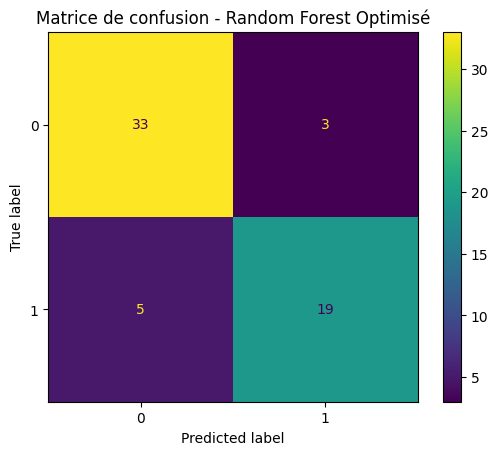

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_opt)
plt.title("Matrice de confusion - Random Forest Optimisé")
plt.show()

Le modèle optimisé produit 5 faux négatifs contre 3 pour le Random Forest de base, confirmant que l'optimisation n'a pas apporté d'amélioration dans ce cas. Le modèle de base reste donc le meilleur choix pour ce dataset.

## Interprétabilité des résultats

Afin de mieux comprendre les décisions du modèle, j'utilise la librairie SHAP (SHapley Additive exPlanations) qui permet d'identifier l'importance et l'impact de chaque variable sur les prédictions.

### SHAP - Feature Importance

In [ ]:
!pip install shap

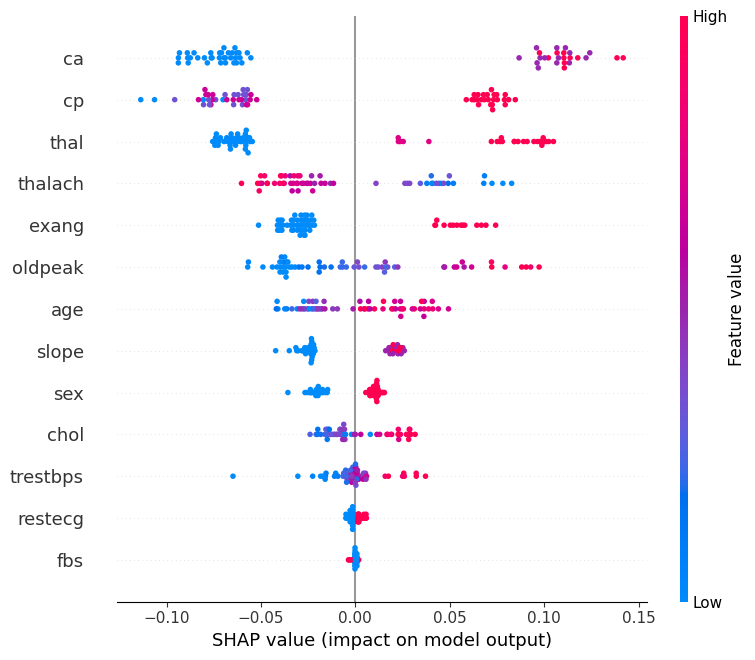

In [ ]:
import shap

# Explainer sur le Random Forest
explainer = shap.TreeExplainer(rf_optimized)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values[:, :, 1], X_test,
                  feature_names=df.drop("target", axis=1).columns)

Le graphique SHAP met en évidence les variables les plus influentes dans la prédiction du modèle. Les variables **ca, cp et thal** apparaissent comme les plus importantes.
On observe que des valeurs élevées de **ca et thal** (points rouges situés à droite) augmentent la probabilité de prédire une maladie cardiaque, tandis que des valeurs élevées de **thalach** (points rouges situés à gauche) ont tendance à diminuer cette probabilité.
Ces résultats sont cohérents avec les observations réalisées lors de l'analyse exploratoire des données (EDA).

##Conclusion

Dans ce projet, j'ai appliqué un pipeline complet de data mining sur le dataset Heart Disease, allant du nettoyage des données et de l'analyse exploratoire jusqu'à la modélisation et l'interprétation des résultats.

Les deux modèles testés donnent de bonnes performances, avec un léger avantage pour le Random Forest qui atteint une accuracy de 88% et seulement 3 faux négatifs. Dans un contexte médical, ce point est particulièrement important car il est préférable de limiter au maximum les cas où un patient malade ne serait pas détecté.

Une optimisation des hyperparamètres via GridSearchCV a également été réalisée. Les résultats montrent que les paramètres par défaut du modèle étaient déjà bien adaptés à ce dataset de taille relativement limitée.

Enfin, l'analyse SHAP m'a permis d'identifier les variables les plus influentes dans les prédictions du modèle, notamment **ca**, **cp** et **thal**. Ces résultats sont cohérents avec les tendances observées lors de l'analyse exploratoire des données.